## Hihello example
### Hihello problem
- 'h', 'i', 'h', 'e', 'l', 'l', 'o' 캐릭터가 존재할 때 다음 캐릭터 예측하는 문제
- h 나 l이 올 경우 어려워짐
- index로 표현
0. h
1. i
2. e
3. i
4. o

#### one-hot encoding
vector 속 하나의 축만 1로 표현하고 나머지는 다 0

In [4]:
# list of available characters

char_set = ['h', 'i', 'e', 'l', 'o']
x_data = [[0, 1, 0, 2, 3, 3]] 
# hihell 까지만. 다음 char를 예측하는 모델이기에 input은 마지막은 자름.
x_one_hot = [[[1, 0, 0, 0, 0],
              [0, 1, 0, 0, 0],
              [1, 0, 0, 0, 0],
              [0, 0, 1, 0, 0],
              [0, 0, 0, 1, 0],
              [0, 0, 0, 1, 0]]]
y_data = [[1, 0, 2, 3, 3, 4]]

## Cross Entropy Loss
- categorical output을 예측하는 데 많이 쓰이는 loss 
- 보통 확률값으로 많이 해석됨
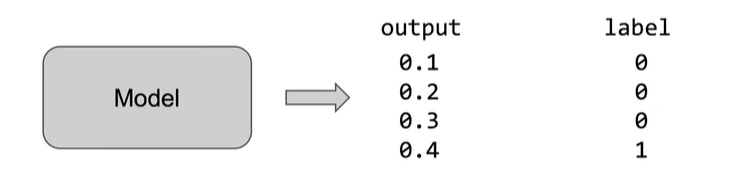

#### loss & optimizer setting
- criterion = torch.nn.CrossEntropyLoss()
- loss = criterion(outputs.view(-1, input_size), Y.veiw(-1))
-> 파라미터 : (모델의 아웃풋, 정답 레이블)

## Code run through (hihello)

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# pytorch의 텐서로 변환하는 작업

X = torch.FloatTensor(x_one_hot)
Y = torch.LongTensor(y_data)

In [11]:
input_size = len(char_set)
hidden_size = len(char_set)
learning_rate = 0.1

rnn = torch.nn.RNN(input_size, hidden_size, batch_first=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn.parameters(), learning_rate)

In [ ]:
# start training
for i in range(1000):
    optimizer.zero_grad()
    outputs, _status = rnn(X)
    loss = criterion(outputs.view(-1, input_size), Y.view(-1))
    loss.backward()
    optimizer.step()

    result = outputs.data.numpy().argmax(axis=2)
    result_str = ''.join([char_set[c] for c in np.squeeze(result)])
    print(i, "loss: ", loss.item(), "prediction: ", result, "true Y: ", y_data, "prediction str: ", result_str)

TypeError: argmax() got an unexpected keyword argument 'dim'

## Code run through (charseq)
data 준비 과정만 조금 차이 있고, 나머지는 hihello랑 동일.
- charseq 는 어떤 문자열이 샘플에 와도 동작하도록 함.

In [7]:
sample = " if you want you"
# make directory

char_set = list(set(sample))
char_dic = {c: i for i, c in enumerate(char_set)}

# hyper parameter
dic_size = len(char_dic)
hidden_size = len(char_dic)
learning_rate = 0.1

# data setting
sample_idx = [char_dic[c] for c in sample] # index만 가져옴
x_data = [sample_idx[:-1]] # 마지막 하나 제외 (X)
x_one_hot = [np.eye(dic_size)[x] for x in x_data]
# np.eye -> identity matrix를 생성 (dic_size x dic_size 크기)
# [x] 인덱싱은 해당 열만 가져오는 원핫 벡터 가져오기 가능.
y_data = [sample_idx[1:]] # 처음 하나 제외 (Y)

X = torch.FloatTensor(x_one_hot)
Y = torch.LongTensor(y_data)

In [10]:
# declare RNN

rnn = torch.nn.RNN(dic_size, hidden_size, batch_first=True)
# batch_first는 (B, S, F)의 output 순서를 보장함.

# loss & optimizer setting
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn.parameters(), learning_rate)

# start training
for i in range(1000):
    optimizer.zero_grad()

    outputs, _status = rnn(X) 
    # _status 는 hidden state, 여기서는 주어지는 모든 인풋을 
    # 다 처리하고 나오는 hidden state이기 때문에 따로 쓰이지 x

    loss = criterion(outputs.view(-1, dic_size), Y.view(-1))
    # batch dimension이 앞으로 오도록 shape을 둘 다 바꿈
    loss.backward()
    optimizer.step() # rnn.parameters() 업데이트

    # 실제로 모델이 어떻게 예측했는지 알아보는 코드
    result = outputs.data.numpy().argmax(axis=2)
    # index가 2인 dimension (어떤 캐릭터인지를 나타내는 dimension) 에서 char이 가장 가능성이 
    # 있는지에 대한  가장 큰 숫자가 있는 인덱스를 가져옴. 
    result_str = ''.join([char_set[c] for c in np.squeeze(result)])
    # 가장 큰 인덱스들만 가져온 후 character set에서 join을 통해 하나의 char로 만듦. 
    print(i, "loss: ", loss.item(), "prediction: ", result, "true Y: ", y_data, "prediction str: ", result_str)

0 loss:  2.3231775760650635 prediction:  [[4 6 8 4 6 9 4 4 4 4 4 4 4 5 4]] true Y:  [[1, 6, 9, 3, 0, 5, 9, 2, 7, 4, 8, 9, 3, 0, 5]] prediction str:  nftnf nnnnnnnun
1 loss:  2.0606915950775146 prediction:  [[2 6 6 9 6 9 0 6 6 4 6 9 6 6 9]] true Y:  [[1, 6, 9, 3, 0, 5, 9, 2, 7, 4, 8, 9, 3, 0, 5]] prediction str:  wff f offnf ff 
2 loss:  1.809295654296875 prediction:  [[2 6 9 3 8 5 0 2 7 0 8 9 3 8 5]] true Y:  [[1, 6, 9, 3, 0, 5, 9, 2, 7, 4, 8, 9, 3, 0, 5]] prediction str:  wf ytuowaot ytu
3 loss:  1.640339970588684 prediction:  [[1 6 9 3 0 5 9 2 7 7 8 9 3 0 5]] true Y:  [[1, 6, 9, 3, 0, 5, 9, 2, 7, 4, 8, 9, 3, 0, 5]] prediction str:  if you waat you
4 loss:  1.5097088813781738 prediction:  [[1 6 9 3 0 5 9 2 7 1 8 9 3 0 5]] true Y:  [[1, 6, 9, 3, 0, 5, 9, 2, 7, 4, 8, 9, 3, 0, 5]] prediction str:  if you wait you
5 loss:  1.4243018627166748 prediction:  [[1 6 9 3 0 5 9 2 7 4 8 9 3 0 5]] true Y:  [[1, 6, 9, 3, 0, 5, 9, 2, 7, 4, 8, 9, 3, 0, 5]] prediction str:  if you want you
6 loss:  1.3